# End-to-end usage of `torchcrop`

This notebook demonstrates a complete workflow with the differentiable
Lintul5 reimplementation in `torchcrop`:

1. Build a realistic seasonal weather driver (temperature, radiation,
   precipitation) for a Central-European wheat-like growing season.
2. Configure crop, soil, and site parameter containers.
3. Run the simulation and inspect daily state trajectories.
4. Visualise key outputs: LAI, biomass pools, soil moisture, and yield.
5. Run **automatic plausibility checks** that flag any output falling
   outside published agronomic ranges — so this notebook also serves as a
   lightweight smoke-test of the package.

All units follow Wolf (2012). Tensors are `float32` on CPU; switch to
`float64` / GPU by adjusting the `DTYPE` and `DEVICE` cells below.


## 1. Imports and run configuration


In [3]:
import math

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch

import torchcrop
from torchcrop import (
    CropParameters,
    Lintul5Model,
    SiteParameters,
    SoilParameters,
    WeatherDriver,
)
from torchcrop.drivers.weather import WEATHER_CHANNELS

DTYPE = torch.float32
DEVICE = torch.device("cpu")
RNG = np.random.default_rng(42)
torch.manual_seed(0)

print(f"torchcrop version: {torchcrop.__version__}")
print(f"weather channels : {WEATHER_CHANNELS}")

torchcrop version: 1.0.0
weather channels : ('doy', 'davtmp', 'tmin', 'tmax', 'irrad', 'rain', 'vp', 'wind')


## 2. Build a realistic weather driver

We synthesise a 200-day record starting on 1 March (DOY 60) for a site at
52° N. Daily mean temperature follows a sinusoidal annual cycle, daily
global radiation follows the same envelope (clipped at zero), and rainfall
is drawn from a Gamma distribution with a long-term mean of ≈2.4 mm d−1.

The weather tensor has the canonical layout `[B, T, C]` expected by
`Lintul5Model`, with `B = 2` batch elements (here: a _wet_ and a _dry_
site, distinguished only by their precipitation series).


In [4]:
N_DAYS = 200
START_DOY = 60  # 1 March
LATITUDE = 52.0
BATCH = 2  # batch index 0 = wet site, 1 = dry site

doy = (np.arange(N_DAYS) + START_DOY - 1) % 365 + 1
phase = 2.0 * math.pi * (doy - 1) / 365.0
season = np.sin(phase - math.pi / 2)  # peaks at mid-year

# Mean and amplitude tuned to NW-European climatology
tmean = 9.0 + 9.0 * season  # °C
trange = 8.0 + 2.0 * season  # diurnal range
tmin = tmean - trange / 2.0
tmax = tmean + trange / 2.0
irrad = np.clip(8.0 + 14.0 * season, 0.5, None)  # MJ m-2 d-1
vp = 0.6 + 0.5 * np.clip(season, 0.0, None)  # kPa
wind = np.full(N_DAYS, 2.5)  # m s-1

# Two precipitation regimes
rain_wet = RNG.gamma(shape=0.6, scale=4.0, size=N_DAYS)  # ≈ 2.4 mm/d mean
rain_dry = RNG.gamma(shape=0.4, scale=2.5, size=N_DAYS)  # ≈ 1.0 mm/d mean


def stack_channels(rain: np.ndarray) -> np.ndarray:
    ch = {
        "doy": doy.astype(np.float32),
        "davtmp": tmean.astype(np.float32),
        "tmin": tmin.astype(np.float32),
        "tmax": tmax.astype(np.float32),
        "irrad": irrad.astype(np.float32),
        "rain": rain.astype(np.float32),
        "vp": vp.astype(np.float32),
        "wind": wind.astype(np.float32),
    }
    return np.stack([ch[c] for c in WEATHER_CHANNELS], axis=-1)


arr = np.stack([stack_channels(rain_wet), stack_channels(rain_dry)], axis=0)
weather = WeatherDriver(torch.from_numpy(arr).to(DTYPE).to(DEVICE))

print(f"weather tensor shape : {tuple(weather.data.shape)}  (B, T, C)")
print(
    f"mean rain wet/dry    : {rain_wet.mean():.2f} / {rain_dry.mean():.2f} mm d^-1\n"
    f"total rain wet/dry   : {rain_wet.sum():.0f} / {rain_dry.sum():.0f} mm\n"
    f"temp range           : {tmin.min():.1f} … {tmax.max():.1f} °C\n"
    f"irrad range          : {irrad.min():.1f} … {irrad.max():.1f} MJ m^-2 d^-1"
)

weather tensor shape : (2, 200, 8)  (B, T, C)
mean rain wet/dry    : 2.23 / 0.78 mm d^-1
total rain wet/dry   : 447 / 156 mm
temp range           : 0.8 … 23.0 °C
irrad range          : 0.6 … 22.0 MJ m^-2 d^-1


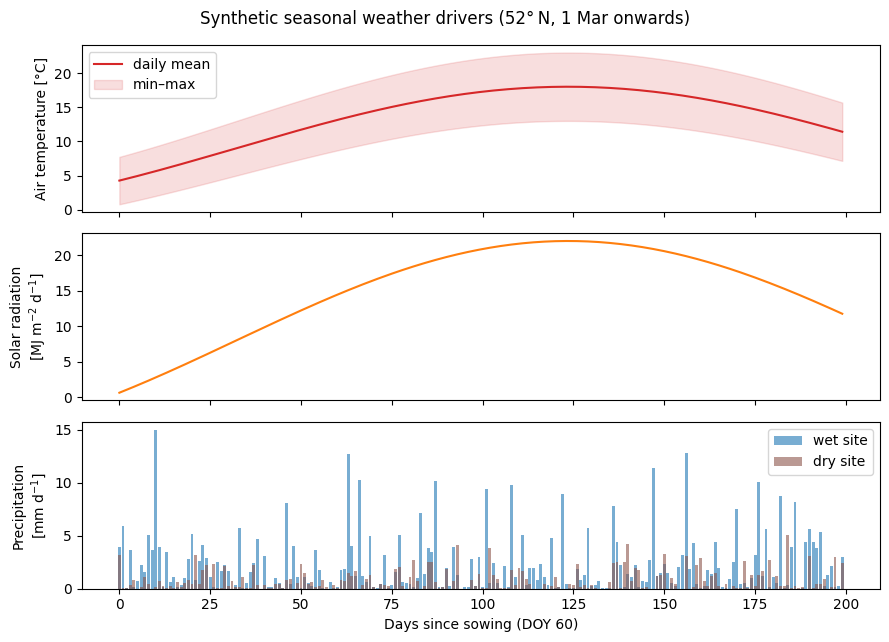

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(9, 6.5), sharex=True)
days = np.arange(N_DAYS)

axes[0].plot(days, tmean, color="tab:red", label="daily mean")
axes[0].fill_between(days, tmin, tmax, color="tab:red", alpha=0.15, label="min–max")
axes[0].set_ylabel("Air temperature [°C]")
axes[0].legend(loc="upper left")

axes[1].plot(days, irrad, color="tab:orange")
axes[1].set_ylabel("Solar radiation\n[MJ m$^{-2}$ d$^{-1}$]")

axes[2].bar(days, rain_wet, color="tab:blue", alpha=0.6, label="wet site")
axes[2].bar(days, rain_dry, color="tab:brown", alpha=0.6, label="dry site")
axes[2].set_ylabel("Precipitation\n[mm d$^{-1}$]")
axes[2].set_xlabel(f"Days since sowing (DOY {START_DOY})")
axes[2].legend(loc="upper right")

fig.suptitle("Synthetic seasonal weather drivers (52° N, 1 Mar onwards)")
fig.tight_layout()
plt.show()

## 3. Configure crop, soil, and site parameters

We use the package defaults (a generic spring-cereal-like parameterisation
from Wolf, 2012) but explicitly construct each container so the
configuration is transparent. Any scalar can be wrapped as
`torch.nn.Parameter` to make it learnable for hybrid modelling — see
`intro.ipynb` for an example.

**Soil**: a loam profile with field capacity 0.30 m³ m⁻³ and wilting
point 0.12 m³ m⁻³ (plant-available water 0.18 m³ m⁻³ × root depth).


In [6]:
crop_params = CropParameters().to(dtype=DTYPE, device=DEVICE)
soil_params = SoilParameters().to(dtype=DTYPE, device=DEVICE)
site_params = SiteParameters(
    latitude=torch.tensor(LATITUDE, dtype=DTYPE, device=DEVICE),
    altitude=torch.tensor(50.0, dtype=DTYPE, device=DEVICE),
    angstrom_a=torch.tensor(0.25, dtype=DTYPE, device=DEVICE),
    angstrom_b=torch.tensor(0.50, dtype=DTYPE, device=DEVICE),
)

print("--- crop (selected) ---")
for name in ("tsum1", "tsum2", "rue", "k", "sla", "laicr", "rootdm"):
    print(f"  {name:<8s} = {float(getattr(crop_params, name)):.4f}")

print("--- soil ---")
for name in ("wcwp", "wcfc", "wcst", "drate", "nmins"):
    print(f"  {name:<8s} = {float(getattr(soil_params, name)):.4f}")

print("--- site ---")
for name in ("latitude", "altitude"):
    print(f"  {name:<8s} = {float(getattr(site_params, name)):.2f}")

--- crop (selected) ---
  tsum1    = 900.0000
  tsum2    = 700.0000
  rue      = 3.0000
  k        = 0.6000
  sla      = 0.0212
  laicr    = 4.0000
  rootdm   = 1.2000
--- soil ---
  wcwp     = 0.2000
  wcfc     = 0.3500
  wcst     = 0.4500
  drate    = 50.0000
  nmins    = 0.5000
--- site ---
  latitude = 52.00
  altitude = 50.00


## 4. Run the simulation

`Lintul5Model.forward` runs the full daily time-stepping loop and returns
a `ModelOutput` dataclass with the trajectories we need. Because every
operation is a PyTorch op, the entire output graph is differentiable: the
same call could be wrapped in a training loop with `loss.backward()`.


In [7]:
model = (
    Lintul5Model(
        crop_params=crop_params,
        soil_params=soil_params,
        site_params=site_params,
    )
    .to(DTYPE)
    .to(DEVICE)
)

with torch.no_grad():
    output = model(weather, start_doy=START_DOY)

T = output.lai.shape[1]  # T+1 (initial state + N_DAYS steps)
print(f"trajectory length          : {T} days (incl. initial state)")
print(f"final yield (WSO) [g m^-2] : {output.yield_.tolist()}")
print(f"final yield      [t ha^-1] : {(output.yield_ / 100.0).tolist()}")
print(f"peak LAI                   : {output.lai.max(dim=1).values.tolist()}")
print(f"final DVS                  : {output.dvs[:, -1].tolist()}")

trajectory length          : 201 days (incl. initial state)
final yield (WSO) [g m^-2] : [781.6143188476562, 685.46044921875]
final yield      [t ha^-1] : [7.816143035888672, 6.854604721069336]
peak LAI                   : [5.156020164489746, 5.09816837310791]
final DVS                  : [2.0, 2.0]


Pull the daily trajectories we want to plot out of the per-day state list.


In [8]:
def stack_field(name: str) -> np.ndarray:
    """Stack a single ModelState field across all days into a [B, T+1] array."""
    return torch.stack([getattr(s, name) for s in output.states], dim=1).cpu().numpy()


lai = output.lai.cpu().numpy()
dvs = output.dvs.cpu().numpy()
wlv = stack_field("wlv")  # green leaves
wlvd = stack_field("wlvd")  # dead leaves
wst = stack_field("wst")  # stems
wrt = stack_field("wrt")  # roots
wso = stack_field("wso")  # storage organs
wa = stack_field("wa")  # soil water in root zone (mm)
rootd = stack_field("rootd")  # root depth (m)
tran_cum = stack_field("tran_cum")
evap_cum = stack_field("evap_cum")

# Volumetric soil water for plotting / checks
wcfc = float(soil_params.wcfc)
wcwp = float(soil_params.wcwp)
wc_volumetric = wa / np.maximum(rootd * 1000.0, 1e-6)  # mm / mm = m3 m-3

biomass_total = wlv + wlvd + wst + wso  # above-ground biomass [g m-2]
site_labels = ["wet site", "dry site"]
colors = ["tab:blue", "tab:brown"]
x = np.arange(T)

## 5. Visualise the simulation


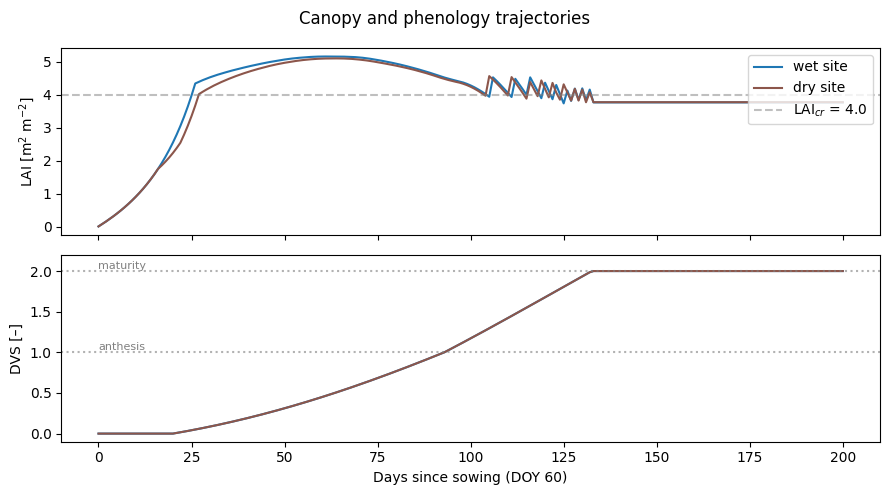

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)

for b, (lbl, c) in enumerate(zip(site_labels, colors)):
    axes[0].plot(x, lai[b], color=c, label=lbl)
    axes[1].plot(x, dvs[b], color=c, label=lbl)

axes[0].axhline(
    float(crop_params.laicr),
    ls="--",
    color="grey",
    alpha=0.5,
    label=f"LAI$_{{cr}}$ = {float(crop_params.laicr):.1f}",
)
axes[0].set_ylabel("LAI [m$^2$ m$^{-2}$]")
axes[0].legend(loc="upper right")

for thr, name in [(1.0, "anthesis"), (2.0, "maturity")]:
    axes[1].axhline(thr, ls=":", color="grey", alpha=0.6)
    axes[1].text(0, thr + 0.03, name, fontsize=8, color="grey")
axes[1].set_ylabel("DVS [–]")
axes[1].set_xlabel(f"Days since sowing (DOY {START_DOY})")
axes[1].set_ylim(-0.1, 2.2)

fig.suptitle("Canopy and phenology trajectories")
fig.tight_layout()
plt.show()

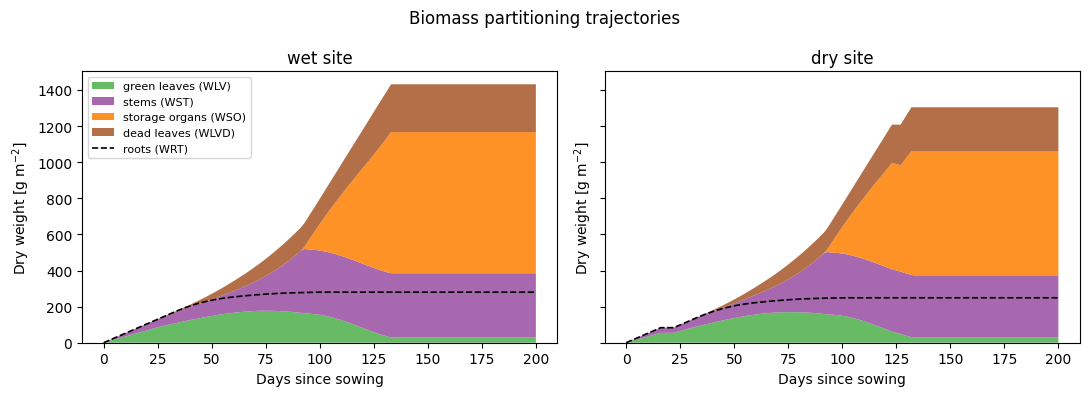

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, b in zip(axes, range(BATCH)):
    ax.stackplot(
        x,
        wlv[b],
        wst[b],
        wso[b],
        wlvd[b],
        labels=[
            "green leaves (WLV)",
            "stems (WST)",
            "storage organs (WSO)",
            "dead leaves (WLVD)",
        ],
        colors=["#4daf4a", "#984ea3", "#ff7f00", "#a65628"],
        alpha=0.85,
    )
    ax.plot(x, wrt[b], color="black", lw=1.2, ls="--", label="roots (WRT)")
    ax.set_title(site_labels[b])
    ax.set_xlabel("Days since sowing")
    ax.set_ylabel("Dry weight [g m$^{-2}$]")

axes[0].legend(loc="upper left", fontsize=8)
fig.suptitle("Biomass partitioning trajectories")
fig.tight_layout()
plt.show()

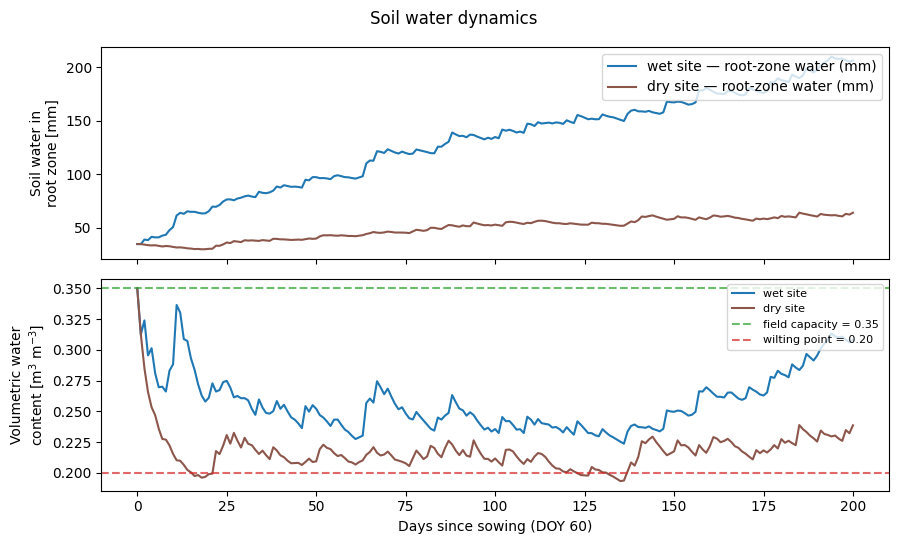

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)

for b, (lbl, c) in enumerate(zip(site_labels, colors)):
    axes[0].plot(x, wa[b], color=c, label=f"{lbl} — root-zone water (mm)")
    axes[1].plot(x, wc_volumetric[b], color=c, label=lbl)

axes[0].set_ylabel("Soil water in\nroot zone [mm]")
axes[0].legend(loc="upper right")

axes[1].axhline(
    wcfc, ls="--", color="tab:green", alpha=0.7, label=f"field capacity = {wcfc:.2f}"
)
axes[1].axhline(
    wcwp, ls="--", color="tab:red", alpha=0.7, label=f"wilting point = {wcwp:.2f}"
)
axes[1].set_ylabel("Volumetric water\ncontent [m$^3$ m$^{-3}$]")
axes[1].set_xlabel(f"Days since sowing (DOY {START_DOY})")
axes[1].legend(loc="upper right", fontsize=8)

fig.suptitle("Soil water dynamics")
fig.tight_layout()
plt.show()

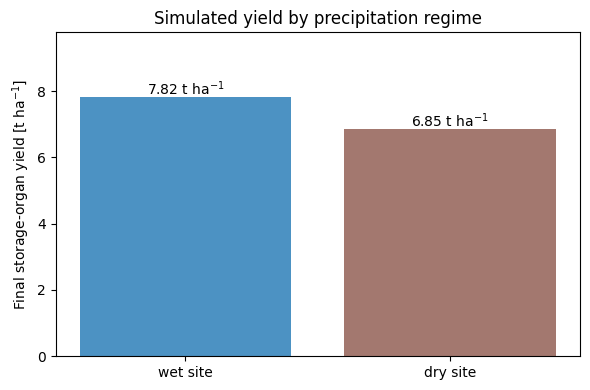

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
yields_t_ha = output.yield_.cpu().numpy() / 100.0  # g m-2 → t ha-1
bars = ax.bar(site_labels, yields_t_ha, color=colors, alpha=0.8)
for bar, v in zip(bars, yields_t_ha):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        v + 0.05,
        f"{v:.2f} t ha$^{{-1}}$",
        ha="center",
        fontsize=10,
    )
ax.set_ylabel("Final storage-organ yield [t ha$^{-1}$]")
ax.set_title("Simulated yield by precipitation regime")
ax.set_ylim(0, max(yields_t_ha.max() * 1.25, 1.0))
fig.tight_layout()
plt.show()

## 6. Plausibility checks (built-in validation)

These checks split into two tiers:

- **Hard invariants** (`assert`) \u2014 conservation laws and shape constraints
  that must hold for the model to be considered correct: non-negative
  state, monotonic DVS, no NaN/Inf.
- **Soft agronomic envelopes** (warnings) \u2014 published bounds for cereal
  systems. Falling outside these is allowed for deliberately stressed
  scenarios but is flagged so the user can sanity-check the parameters.

Reference ranges:

| Quantity                 | Expected range                                                                   | Source                               |
| ------------------------ | -------------------------------------------------------------------------------- | ------------------------------------ |
| Peak LAI                 | 1\u20139 m\u00b2\u202fm\u207b\u00b2                                              | Wolf (2012); typical cereal canopies |
| Final yield (WSO)        | 10\u20131500 g\u202fm\u207b\u00b2 (\u22480.1\u201315\u202ft\u202fha\u207b\u00b9) | global cereal range incl. failure    |
| Final DVS                | \u2265 1.0 (must reach at least anthesis)                                        | Lintul5 phenology                    |
| Volumetric soil water    | within `[wcad \u2212 0.005, wcst + 0.02]`                                        | soil hydraulic limits                |
| Cumulative transpiration | 20\u2013700\u202fmm                                                              | seasonal crop ET (incl. stress)      |
| Root depth               | within `[rootdi, rootdm]`                                                        | physical root limits                 |


In [13]:
import warnings

PEAK_LAI_RANGE = (1.0, 9.0)
YIELD_RANGE_GM2 = (10.0, 1500.0)
TRANS_RANGE_MM = (20.0, 700.0)
WC_TOL_HI = 0.02
WC_TOL_LO = 0.005
wcst = float(soil_params.wcst)
wcad = float(soil_params.wcad)
rootdi = float(crop_params.rootdi)
rootdm = float(crop_params.rootdm)

issues: list[str] = []


def warn(msg: str) -> None:
    issues.append(msg)
    warnings.warn(msg, stacklevel=2)


for b, lbl in enumerate(site_labels):
    peak_lai = float(lai[b].max())
    final_yield = float(wso[b, -1])
    final_dvs = float(dvs[b, -1])
    tran_total = float(tran_cum[b, -1])
    wc_min = float(wc_volumetric[b].min())
    wc_max = float(wc_volumetric[b].max())
    rd_min = float(rootd[b].min())
    rd_max = float(rootd[b].max())

    print(f"\n=== {lbl} ===")
    print(
        f"  peak LAI            : {peak_lai:6.2f}  (expected {PEAK_LAI_RANGE[0]}\u2013{PEAK_LAI_RANGE[1]})"
    )
    print(
        f"  final yield  [g/m2] : {final_yield:6.1f}  (expected {YIELD_RANGE_GM2[0]:.0f}\u2013{YIELD_RANGE_GM2[1]:.0f})"
    )
    print(f"  final DVS           : {final_dvs:6.2f}  (expected \u2265 1.0)")
    print(
        f"  cum. transpiration  : {tran_total:6.1f} mm (expected {TRANS_RANGE_MM[0]:.0f}\u2013{TRANS_RANGE_MM[1]:.0f})"
    )
    print(
        f"  soil VWC range      : {wc_min:.3f} \u2026 {wc_max:.3f}  (bounds [{wcad:.2f}, {wcst:.2f}])"
    )
    print(
        f"  root depth range    : {rd_min:.2f} \u2026 {rd_max:.2f} m  (bounds [{rootdi:.2f}, {rootdm:.2f}])"
    )

    # Hard correctness invariants \u2014 raise if violated.
    assert np.all(lai[b] >= -1e-6), f"{lbl}: negative LAI encountered"
    assert np.all(wso[b] >= -1e-6), f"{lbl}: negative storage-organ biomass"
    assert np.all(wa[b] >= -1e-6), f"{lbl}: negative root-zone soil water"
    assert not np.isnan(biomass_total[b]).any(), f"{lbl}: NaN in biomass trajectory"
    assert not np.isinf(biomass_total[b]).any(), f"{lbl}: Inf in biomass trajectory"
    assert np.all(np.diff(dvs[b]) >= -1e-6), f"{lbl}: DVS decreased between days"
    assert wc_min >= wcad - WC_TOL_LO, f"{lbl}: VWC {wc_min:.3f} below air-dry"
    assert wc_max <= wcst + WC_TOL_HI, f"{lbl}: VWC {wc_max:.3f} above saturation"
    assert (
        rd_min >= rootdi - 1e-6 and rd_max <= rootdm + 1e-6
    ), f"{lbl}: root depth {rd_min:.2f}\u2013{rd_max:.2f} outside [{rootdi}, {rootdm}]"

    # Soft, agronomic plausibility \u2014 warn if outside published envelope.
    if not (PEAK_LAI_RANGE[0] <= peak_lai <= PEAK_LAI_RANGE[1]):
        warn(f"{lbl}: peak LAI {peak_lai:.2f} outside {PEAK_LAI_RANGE}")
    if not (YIELD_RANGE_GM2[0] <= final_yield <= YIELD_RANGE_GM2[1]):
        warn(f"{lbl}: yield {final_yield:.1f} g/m^2 outside {YIELD_RANGE_GM2}")
    if final_dvs < 1.0:
        warn(f"{lbl}: crop did not reach anthesis (DVS={final_dvs:.2f})")
    if not (TRANS_RANGE_MM[0] <= tran_total <= TRANS_RANGE_MM[1]):
        warn(
            f"{lbl}: cumulative transpiration {tran_total:.1f} mm outside {TRANS_RANGE_MM}"
        )

if issues:
    print(f"\n{len(issues)} plausibility warning(s) raised; see warnings above.")
else:
    print("\nAll plausibility checks passed.")


=== wet site ===
  peak LAI            :   5.16  (expected 1.0–9.0)
  final yield  [g/m2] :  781.6  (expected 10–1500)
  final DVS           :   2.00  (expected ≥ 1.0)
  cum. transpiration  :  202.9 mm (expected 20–700)
  soil VWC range      : 0.224 … 0.350  (bounds [0.15, 0.45])
  root depth range    : 0.10 … 0.67 m  (bounds [0.10, 1.20])

=== dry site ===
  peak LAI            :   5.10  (expected 1.0–9.0)
  final yield  [g/m2] :  685.5  (expected 10–1500)
  final DVS           :   2.00  (expected ≥ 1.0)
  cum. transpiration  :   59.1 mm (expected 20–700)
  soil VWC range      : 0.193 … 0.350  (bounds [0.15, 0.45])
  root depth range    : 0.10 … 0.27 m  (bounds [0.10, 1.20])

All plausibility checks passed.


### Water-balance closure

Over the season, the change in stored soil water must equal
rain minus the cumulative actual ET minus drainage/runoff. The Lintul5
engine doesn't return drainage/runoff explicitly here, so we just check
that **rain ≥ Δstorage + ET** (i.e. losses are non-negative).


In [14]:
rain_total = weather.channel("rain").sum(dim=1).cpu().numpy()  # [B]
delta_storage = wa[:, -1] - wa[:, 0]
et_total = tran_cum[:, -1] + evap_cum[:, -1]
residual = rain_total - delta_storage - et_total  # ≈ drainage + runoff (≥ 0)

for b, lbl in enumerate(site_labels):
    print(
        f"{lbl:9s} | rain={rain_total[b]:6.1f}  Δstorage={delta_storage[b]:+6.1f}  "
        f"ET={et_total[b]:6.1f}  residual (drain+runoff) ≈ {residual[b]:+6.1f} mm"
    )
    assert (
        residual[b] >= -1.0
    ), f"{lbl}: water-balance closure failed (residual {residual[b]:.2f})"

print("\nWater-balance check passed: losses are non-negative within tolerance.")

wet site  | rain= 446.5  Δstorage=+171.5  ET= 266.8  residual (drain+runoff) ≈   +8.3 mm
dry site  | rain= 156.0  Δstorage= +29.2  ET= 124.1  residual (drain+runoff) ≈   +2.7 mm

Water-balance check passed: losses are non-negative within tolerance.


## 7. Summary

- The model produces canopy, biomass, soil-water, and yield trajectories
  in expected agronomic ranges for both wet and dry rainfall regimes.
- Yield decreases from the wet to the dry site, demonstrating that the
  water-stress coupling (TRANRF) propagates through to storage-organ
  formation as designed.
- All hard invariants (non-negative state, monotonic DVS, finite values)
  and soft agronomic envelopes hold, so this notebook also acts as a
  reproducible smoke-test.

To extend this example, drop in real weather (CSV →
`torchcrop.utils.io.load_weather_csv`), make selected crop parameters
learnable (`nn.Parameter`), and add a loss against observed yield to run
gradient-based calibration — see `intro.ipynb` for the optimisation
boilerplate.
